# LieSolver Demo

Train a model on the 1D wave equation and visualize results.

In [5]:
from pathlib import Path
import numpy as np

from liesolver.utils import load_config
from liesolver.utils.io import create_output_dir, configure_logging
from liesolver.trainer import Trainer
from liesolver.plotting import plot_2d_domain, plot_ic_bc, plot_fit_history

Experiment folder: outputs/demo
Loaded: data/wave_1d-c4f63ae858d30d76.npz | MSE_pde=0.00e+00 | MSE_icbc=6.94e-14
ConstraintSet with 4 constraints, 5000 total samples:
  Constraint('IC_u0', n=1500, deriv=(0, 0), w=1.0)
  Constraint('IC_ut0', n=1000, deriv=(0, 1), w=1.0)
  Constraint('BC_left', n=1250, deriv=(0, 0), w=1.0)
  Constraint('BC_right', n=1250, deriv=(0, 0), w=1.0)
Action           MSEtrain   MSEtest   MSEdomain Trafos•start_fun         Parameters
Add 1  a:-0.46 | 2.00e-02 | 2.0e-02 | 3.2e-02 | T4•T1( sin(x)*cos(t) ) | θ1:3.1e+00 θ4:3.0e+00
Add 2  a:-0.33 | 3.59e-03 | 3.6e-03 | 6.2e-03 | T4•T1( sin(x)*cos(t) ) | θ1:3.7e-02 θ4:9.4e+00
Add 3  a:+0.14 | 6.26e-04 | 6.3e-04 | 1.2e-03 | T4•T1( sin(x)*cos(t) ) | θ1:2.0e-01 θ4:1.6e+01
Add 4  a:+0.04 | 4.06e-04 | 4.1e-04 | 6.7e-04 | T4•T1( sin(x)*cos(t) ) | θ1:3.0e+00 θ4:2.2e+01
Add 5  a:+0.02 | 3.00e-04 | 3.0e-04 | 6.2e-04 | T4•T1( sin(x)*cos(t) ) | θ1:2.0e+00 θ4:9.7e+00
Refine batch   | 1.35e-05 | 1.3e-05 | 2.3e-05
Add 6  a:-9e-3 | 1

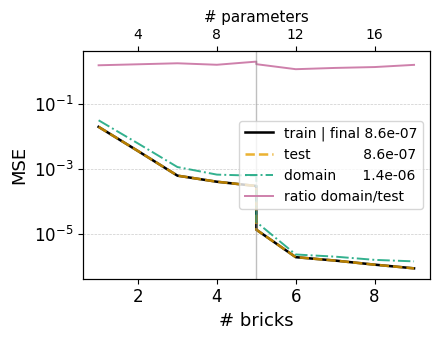

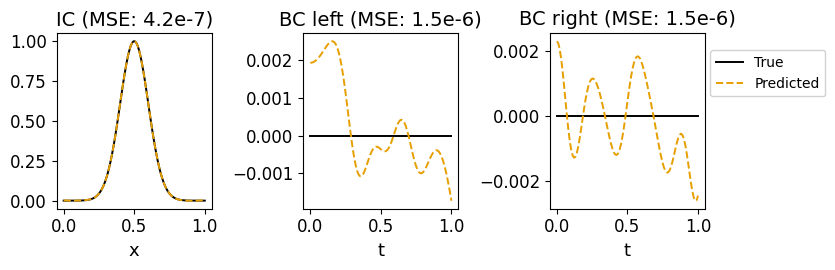

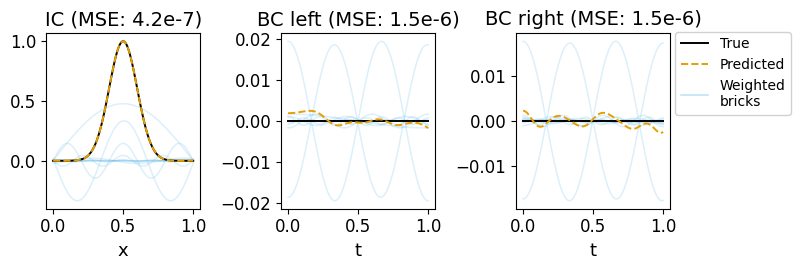

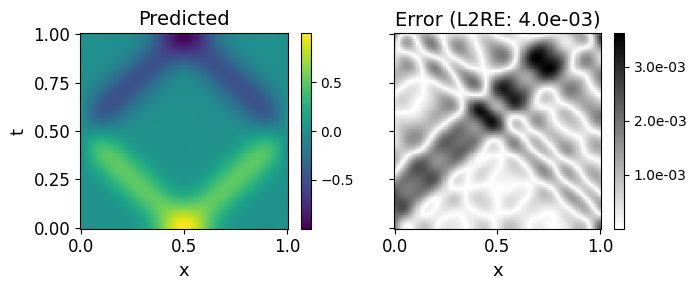

In [7]:
# Load config
cfg = load_config('configs/wave_1d.yaml', overrides=[])
cfg['fit']['max_bricks'] = 20

# Setup output
out_dir = Path('outputs/demo')
out_dir.mkdir(parents=True, exist_ok=True)
configure_logging(out_dir / 'run.log')

# Train
trainer = Trainer(cfg, out_dir)
trainer.init_model()
state = trainer.fit()

In [9]:
model, data = trainer.model, trainer.data
domain_mse = float(np.mean((model(data.domain_x) - data.domain_y)**2))
domain_l2re = np.sqrt(domain_mse / np.mean(data.domain_y**2))

print(f"Bricks: {len(model.bricks)}, Parameters: {sum(b.params.size for b in model.bricks)}")
print(f"Train MSE: {model.mse:.2e}, Domain L2RE: {domain_l2re:.2e}")

Bricks: 9, Parameters: 18
Train MSE: 8.63e-07, Domain L2RE: 4.00e-03
